# 🚗 Car Price Prediction using Machine Learning

This project analyzes a large automobile dataset and builds machine learning models to predict car prices based on features like power, mileage, and vehicle type.

## 📚 Importing Libraries

We use:

- Pandas & NumPy → Data handling  
- Matplotlib & Seaborn → Visualization  


In [511]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading Dataset

The dataset contains over **371,528 car listings** with features like price, brand, fuel type,registration details e.t.c .

In [512]:
df = pd.read_csv("/content/autos.csv")

## 🔍 Data Exploration

We examine:

- Dataset shape  
- Column types  
- Missing values  

This helps understand data structure and quality.

In [513]:
df.shape

(371528, 21)

In [514]:
df.head()

,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [515]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

In [516]:
df['gearbox'].unique()

array(['manuell', 'automatik', nan], dtype=object)

## ⚠️ Handling Missing Values

Missing values in categorical columns like:

- vehicleType  
- gearbox  
- fuelType  

are filled with default values such as 'unknown' to maintain consistency.

In [517]:
df['vehicleType'] = df['vehicleType'].fillna('unknown')
df['gearbox'] = df['gearbox'].fillna('nan')
df['model'] = df['model'].fillna('unknown')
df['fuelType'] = df['fuelType'].fillna('unknown')
df['notRepairedDamage'] = df['notRepairedDamage'].fillna('nan')

In [518]:
df.isna().sum()

,0
index,0
dateCrawled,0
name,0
seller,0
offerType,0
price,0
abtest,0
vehicleType,0
yearOfRegistration,0
gearbox,0


## 🧹 Data Cleaning

- Removed unnecessary columns (index, name, postalCode)  
- Converted date columns into datetime format  
- Ensured clean and usable dataset  

In [519]:
#df['dateCreated'] = df['dateCreated'].fillna('')
df['postalCode'] = df['postalCode'] .fillna('unknown')
#df['lastSeen'] = df['lastSeen'].fillna('')
df.columns = df.columns.str.strip()

In [520]:
df.duplicated().sum()

np.int64(0)

In [521]:
df['dateCrawled'] = pd.to_datetime(df['dateCrawled'])
df['dateCreated'] = pd.to_datetime(df['dateCreated'])
df['lastSeen'] = pd.to_datetime(df['lastSeen'])

In [522]:
df=df.drop(['index', 'name', 'nrOfPictures', 'postalCode'], axis=1, )

In [523]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   dateCrawled          371528 non-null  datetime64[ns]
 1   seller               371528 non-null  object        
 2   offerType            371528 non-null  object        
 3   price                371528 non-null  int64         
 4   abtest               371528 non-null  object        
 5   vehicleType          371528 non-null  object        
 6   yearOfRegistration   371528 non-null  int64         
 7   gearbox              371528 non-null  object        
 8   powerPS              371528 non-null  int64         
 9   model                371528 non-null  object        
 10  kilometer            371528 non-null  int64         
 11  monthOfRegistration  371528 non-null  int64         
 12  fuelType             371528 non-null  object        
 13  brand         

## 🚫 Removing Invalid Data

- Removed cars with price ≤ 0  
- Filtered unrealistic prices (above 150,000)  
- Filtered invalid years and power values  

This ensures realistic and meaningful analysis.

In [524]:
df = df[df['price'] > 0]

In [525]:
df['price'].describe()

,price
count,3.607500e+05
mean,1.781186e+04
std,3.641156e+06
min,1.000000e+00
25%,1.250000e+03
50%,3.000000e+03
75%,7.490000e+03
max,2.147484e+09


In [526]:
# Keep only realistic prices
df = df[(df['price'] > 100) & (df['price'] < 150000)]

# Verify the result
print(f"New shape: {df.shape}")
df['price'].describe()

New shape: (356940, 17)


,price
count,356940.000000
mean,5886.800280
std,7969.866873
min,101.000000
25%,1299.000000
50%,3100.000000
75%,7500.000000
max,149999.000000


In [527]:
df['dateCrawled'].unique()

<DatetimeArray>
['2016-03-24 11:52:17', '2016-03-24 10:58:45', '2016-03-14 12:52:21',
 '2016-03-17 16:54:04', '2016-03-31 17:25:20', '2016-04-04 17:36:23',
 '2016-04-01 20:48:51', '2016-04-04 23:42:13', '2016-03-17 10:53:50',
 '2016-03-26 19:54:18',
 ...
 '2016-03-20 18:47:59', '2016-03-16 17:06:19', '2016-04-02 16:43:27',
 '2016-03-06 21:11:23', '2016-04-04 09:57:12', '2016-03-09 13:37:43',
 '2016-03-19 19:53:49', '2016-03-14 17:48:27', '2016-03-19 18:57:12',
 '2016-03-07 19:39:19']
Length: 272520, dtype: datetime64[ns]

In [528]:
df = df[(df['yearOfRegistration']>1900) & (df['yearOfRegistration']<=2026)]
df = df[(df['powerPS'] > 10) & (df['powerPS'] < 1000)]
df.shape

(321209, 17)

## 📉 Price Distribution

Histogram shows that:

- Most cars fall in lower price range  
- Distribution is right-skewed  
- Few high-price outliers exist  

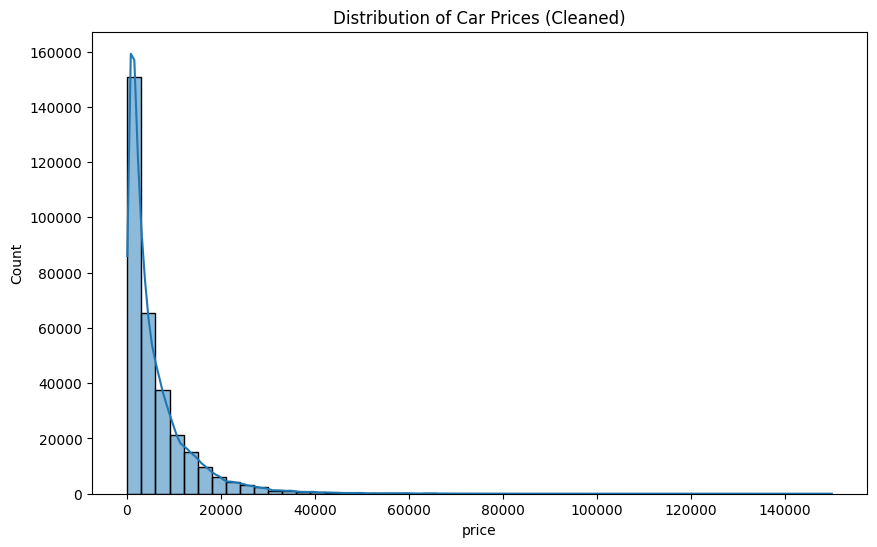

In [529]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Car Prices (Cleaned)')
plt.show()

## 📅 Year of Registration Analysis

Most vehicles are registered after 2000, indicating modern car dominance in the dataset.

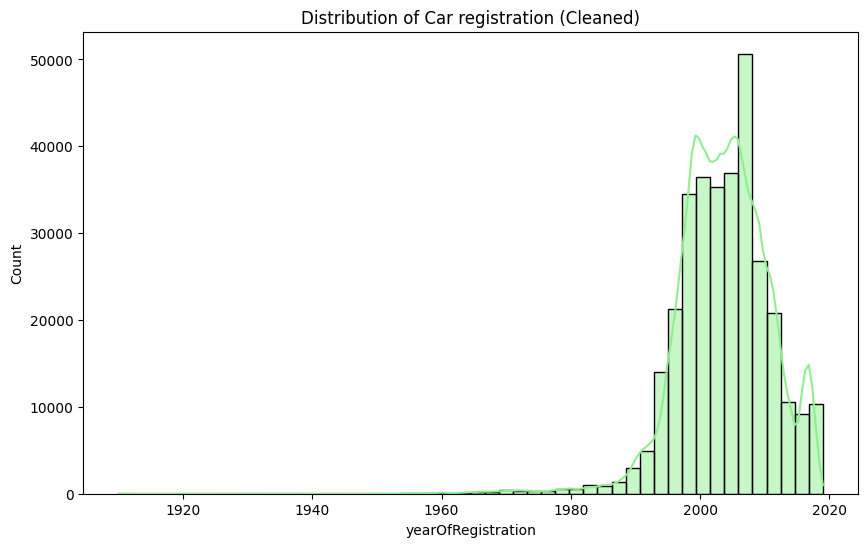

In [530]:
plt.figure(figsize=(10,6))
sns.histplot(df['yearOfRegistration'], bins=50, kde=True,color='lightgreen')
plt.title('Distribution of Car registration (Cleaned)')
plt.show()

## ⚙️ Gearbox Analysis

Boxplot shows variation in car registration year across gearbox types.

Insight:
- Automatic cars tend to be newer compared to manual cars  

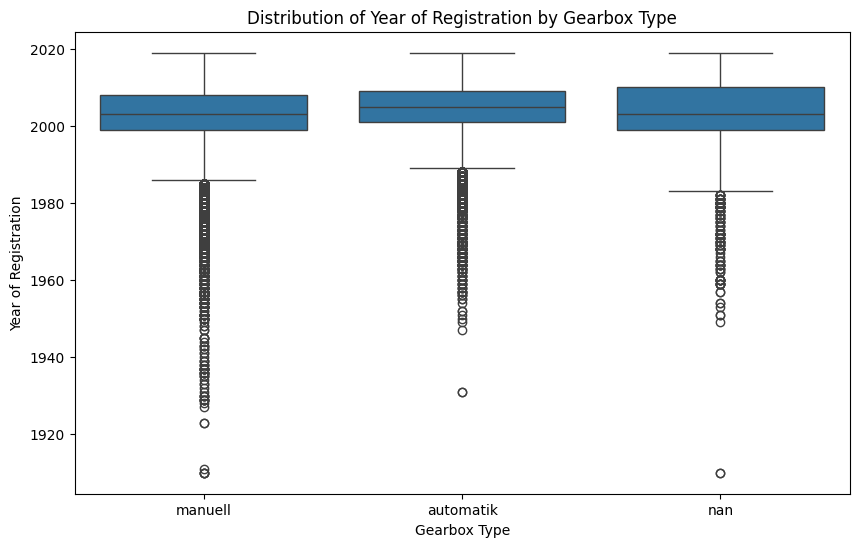

In [531]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['gearbox'], y=df['yearOfRegistration'])
plt.title('Distribution of Year of Registration by Gearbox Type')
plt.xlabel('Gearbox Type')
plt.ylabel('Year of Registration')
plt.show()

## 🏷️ Brand-wise Price Analysis

Top 20 brands have significantly higher average prices.

Insight:
- Premium brands dominate higher price segments  

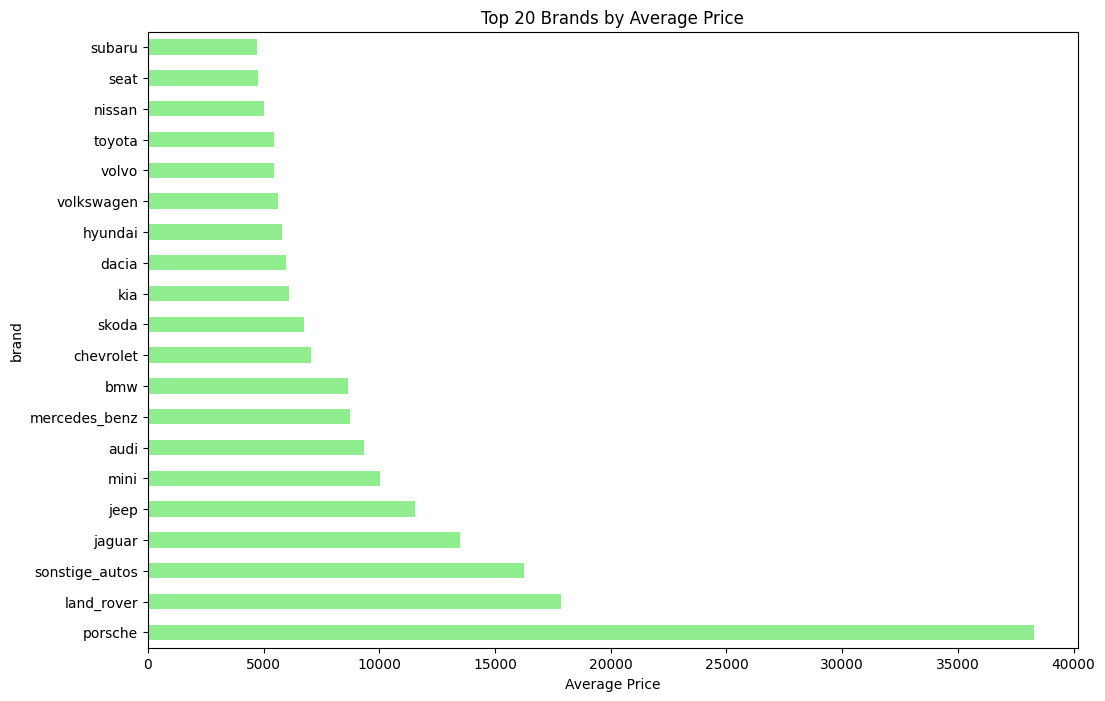

In [532]:
plt.figure(figsize=(12,8))
df.groupby('brand')['price'].mean().sort_values(ascending=False).head(20).plot(kind='barh', color='lightgreen')
plt.title('Top 20 Brands by Average Price')
plt.xlabel('Average Price')
plt.show()

## 👤 Seller Analysis

Most listings are from private sellers rather than commercial dealers.

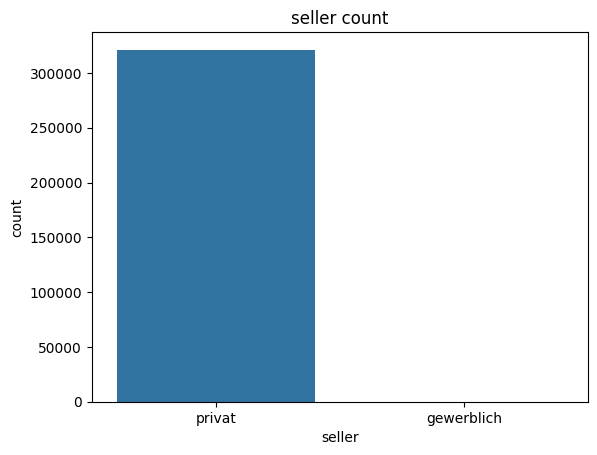

In [533]:
sns.countplot(
    data = df,
    x = 'seller'
)
plt.title("seller count")
plt.show()

## 🧪 A/B Test Analysis

Dataset includes test/control segmentation, useful for experimentation analysis.

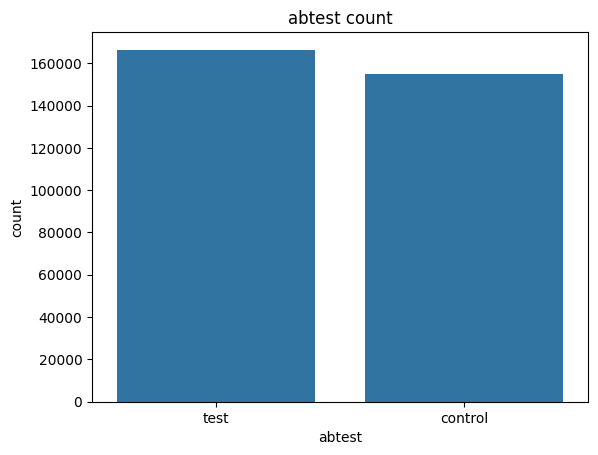

In [534]:
sns.countplot(
    data = df,
    x = 'abtest'
)
plt.title("abtest count")
plt.show()

## 🚘 Model-wise Price Analysis

Prices vary significantly across car models, indicating strong product differentiation.

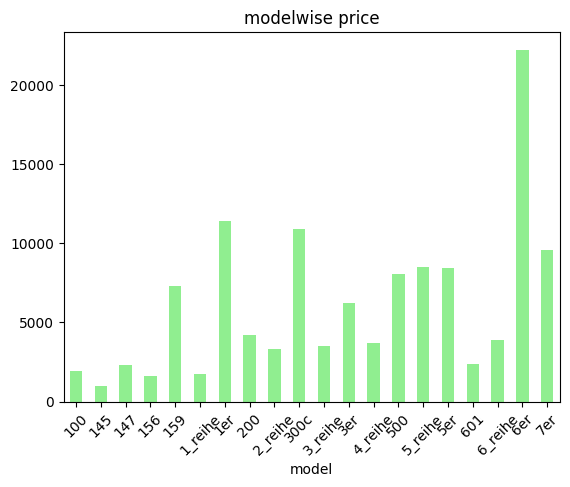

In [535]:
df.groupby('model')['price'].mean().head(20).plot(kind='bar',color="lightgreen")
plt.title("modelwise price")
plt.xticks(rotation=45)
plt.show()

## ⛽ Fuel Type Analysis

Fuel type impacts pricing:

- Diesel cars tend to have higher prices  
- Electric and hybrid segments are emerging  

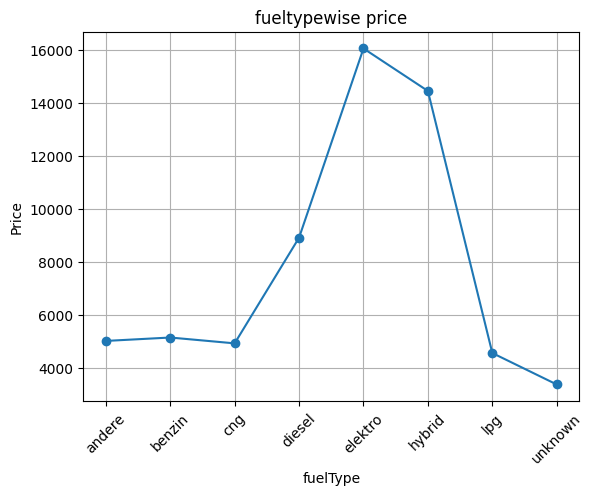

In [536]:
df.groupby('fuelType')['price'].mean().plot(kind="line",marker="o",grid=True)
plt.title("fueltypewise price")
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.show()

🤖 MACHINE LEARNING SECTION

## ⚙️ Feature Engineering

- Selected relevant features  
- Applied one-hot encoding for categorical variables  
- Prepared dataset for machine learning models  

In [578]:
features = ['yearOfRegistration', 'powerPS', 'kilometer', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
df_ml = df[features + ['price']]
df_ml = pd.get_dummies(df_ml, columns=['vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage'], drop_first=True)
df_ml.head()

,yearOfRegistration,powerPS,kilometer,price,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,...,gearbox_nan,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,fuelType_unknown,notRepairedDamage_nan,notRepairedDamage_nein
1,2011,190,125000,18300,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2004,163,125000,9800,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
3,2001,75,150000,1500,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,True
4,2008,69,90000,3600,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
5,1995,102,150000,650,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False


In [538]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 321209 entries, 1 to 371527
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   yearOfRegistration      321209 non-null  int64
 1   powerPS                 321209 non-null  int64
 2   kilometer               321209 non-null  int64
 3   price                   321209 non-null  int64
 4   vehicleType_bus         321209 non-null  bool 
 5   vehicleType_cabrio      321209 non-null  bool 
 6   vehicleType_coupe       321209 non-null  bool 
 7   vehicleType_kleinwagen  321209 non-null  bool 
 8   vehicleType_kombi       321209 non-null  bool 
 9   vehicleType_limousine   321209 non-null  bool 
 10  vehicleType_suv         321209 non-null  bool 
 11  vehicleType_unknown     321209 non-null  bool 
 12  gearbox_manuell         321209 non-null  bool 
 13  gearbox_nan             321209 non-null  bool 
 14  fuelType_benzin         321209 non-null  bool 
 15  fuelT

## 🔗 Correlation Analysis

Key insights:

- Power (PS) strongly affects price  
- Kilometer has negative correlation with price  
- Newer cars are more expensive  

In [539]:
df_ml.corr()

,yearOfRegistration,powerPS,kilometer,price,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,...,gearbox_nan,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,fuelType_unknown,notRepairedDamage_nan,notRepairedDamage_nein
yearOfRegistration,1.000000,0.156529,-0.294976,0.330644,0.038042,-0.061716,-0.086248,-0.063296,0.017988,-0.119196,...,0.004176,-0.260222,0.015991,0.240302,0.013932,0.024263,-0.026601,0.075210,-0.048672,0.102335
powerPS,0.156529,1.000000,-0.024607,0.577465,-0.031753,0.106184,0.209843,-0.443695,0.125023,0.126532,...,-0.050595,-0.148598,-0.014845,0.167106,-0.003563,0.001328,0.068163,-0.051232,-0.083857,0.108594
kilometer,-0.294976,-0.024607,1.000000,-0.440951,0.024508,-0.090785,-0.019360,-0.102321,0.124379,0.034127,...,0.002606,-0.122469,0.002267,0.092316,-0.029604,-0.030774,0.052488,0.050284,0.086892,-0.131587
price,0.330644,0.577465,-0.440951,1.000000,0.028337,0.143218,0.143159,-0.209123,-0.007943,-0.000840,...,-0.041366,-0.162665,-0.006158,0.222623,0.018451,0.028235,-0.024849,-0.088396,-0.134385,0.212240
vehicleType_bus,0.038042,-0.031753,0.024508,0.028337,1.000000,-0.081608,-0.072781,-0.160900,-0.148855,-0.186771,...,-0.015477,-0.183934,0.050103,0.213954,-0.003915,-0.006087,0.004850,-0.047551,-0.043434,0.035041
vehicleType_cabrio,-0.061716,0.106184,-0.090785,0.143218,-0.081608,1.000000,-0.063353,-0.140056,-0.129571,-0.162576,...,-0.000554,0.142381,-0.009595,-0.128113,-0.001573,-0.007394,-0.010436,-0.034783,-0.035248,0.055104
vehicleType_coupe,-0.086248,0.209843,-0.019360,0.143159,-0.072781,-0.063353,1.000000,-0.124908,-0.115557,-0.144992,...,-0.009261,0.088765,-0.008704,-0.079751,0.001862,0.001892,0.003242,-0.027275,-0.012175,0.015924
vehicleType_kleinwagen,-0.063296,-0.443695,-0.102321,-0.209123,-0.160900,-0.140056,-0.124908,1.000000,-0.255466,-0.320538,...,0.013787,0.262583,-0.007010,-0.249500,0.011950,-0.005304,-0.037547,-0.033210,0.007956,-0.019320
vehicleType_kombi,0.017988,0.125023,0.124379,-0.007943,-0.148855,-0.129571,-0.115557,-0.255466,1.000000,-0.296543,...,-0.030488,-0.204699,0.006421,0.236086,-0.004771,-0.006917,0.010171,-0.043308,-0.026171,0.010300
vehicleType_limousine,-0.119196,0.126532,0.034127,-0.000840,-0.186771,-0.162576,-0.144992,-0.320538,-0.296543,1.000000,...,-0.040106,0.047793,-0.018638,-0.016863,-0.002800,0.018194,0.013810,-0.070833,-0.046437,0.043823


<Axes: >

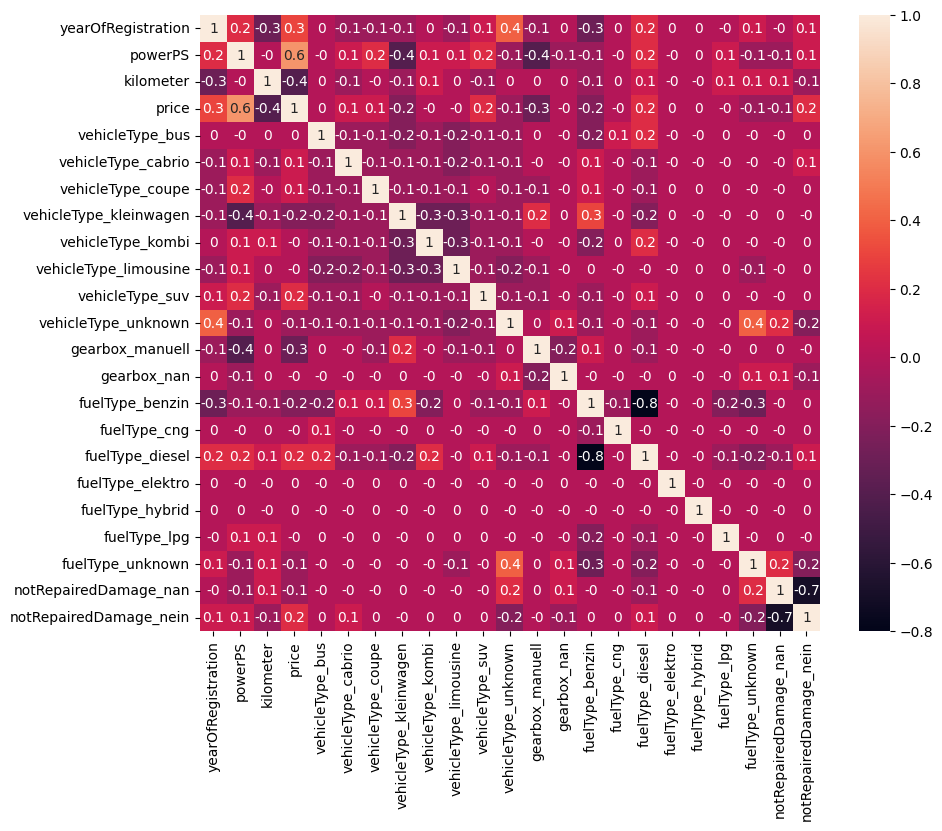

In [540]:
plt.figure(figsize=(10,8))
sns.heatmap(df_ml.corr().round(1),annot=True)

## Converting data into 2 coloums
- x is independent values(All coloums without price coloum)
- y is traget value(price coloum)

In [541]:
X = df_ml.drop('price', axis=1)
y = df_ml['price']

In [542]:
X

,yearOfRegistration,powerPS,kilometer,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,...,gearbox_nan,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,fuelType_unknown,notRepairedDamage_nan,notRepairedDamage_nein
1,2011,190,125000,False,False,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,2004,163,125000,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,True,False
3,2001,75,150000,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
4,2008,69,90000,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
5,1995,102,150000,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371520,2004,225,150000,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
371524,2000,101,125000,False,True,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
371525,1996,102,150000,True,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
371526,2002,100,150000,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False


In [543]:
y

,price
1,18300
2,9800
3,1500
4,3600
5,650
...,...
371520,3200
371524,1199
371525,9200
371526,3400


## 🔀 Train-Test Split

from sklearn.modelselection we are importing train,test,split

Dataset is split into:

- 75% training data  
- 25% testing data  

This ensures proper model evaluation.

In [544]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=80)

In [545]:
df.shape

(321209, 17)

In [546]:
X_train

,yearOfRegistration,powerPS,kilometer,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,...,gearbox_nan,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,fuelType_unknown,notRepairedDamage_nan,notRepairedDamage_nein
33404,2010,200,70000,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
5740,2003,58,125000,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True
83127,2013,170,50000,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
10629,1996,55,80000,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
186759,2004,101,150000,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215563,2002,101,150000,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
116336,2001,75,150000,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
325518,2007,111,125000,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
44224,2009,60,125000,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,True


In [547]:
y_train

,price
33404,8990
5740,1500
83127,23250
10629,250
186759,3250
...,...
215563,2800
116336,999
325518,3800
44224,4500


In [548]:
X_test

,yearOfRegistration,powerPS,kilometer,vehicleType_bus,vehicleType_cabrio,vehicleType_coupe,vehicleType_kleinwagen,vehicleType_kombi,vehicleType_limousine,vehicleType_suv,...,gearbox_nan,fuelType_benzin,fuelType_cng,fuelType_diesel,fuelType_elektro,fuelType_hybrid,fuelType_lpg,fuelType_unknown,notRepairedDamage_nan,notRepairedDamage_nein
202636,1998,116,150000,False,False,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False
130890,2002,70,150000,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
84819,1978,54,70000,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
325092,2012,140,150000,False,False,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
44418,2001,170,150000,False,False,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200624,2010,170,150000,False,False,False,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
309671,1999,143,150000,False,False,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
250164,2001,60,150000,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
66829,2012,160,50000,False,False,True,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True


In [549]:
y_test

,price
202636,700
130890,550
84819,3300
325092,16800
44418,1399
...,...
200624,12500
309671,3450
250164,2100
66829,18300


In [550]:
y_test.shape

(80303,)

In [551]:
y_train.shape

(240906,)

In [552]:
X_test.shape

(80303, 22)

In [553]:
X_train.shape

(240906, 22)

## 📈 Linear Regression Model
- Importing linear regession model from sklearn.linear_model

A basic regression model is trained to predict car prices.

In [609]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [610]:
y_pred = model.predict(X_test)
y_pred

array([ -725.02133908,  2623.91504485,  1221.08566912, ...,
        2092.32304109, 16472.81305875,  8410.58414221])

## 📊 Model Evaluation

Results:

- High error (MAE ~3060)  
- Low R² score (~0.27)  

Insight:
- Linear regression underperforms due to non-linear relationships  

In [611]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print(mean_squared_error(y_pred,y_test))

27896598.242088273


In [612]:
print(mean_absolute_error(y_pred,y_test))

3060.514230060473


In [613]:
r2_score(y_pred,y_test)

0.2724550245418492

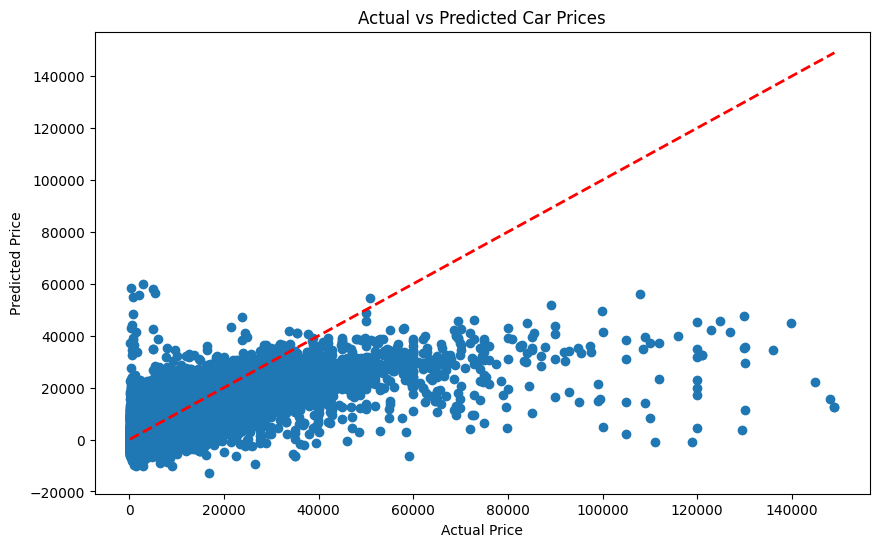

In [614]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

## 🔄 Log Transformation

Applying log transformation on price improves performance:

- R² improves significantly (~0.67)  
- Better prediction accuracy  

In [615]:
# 1. Transform the target (Price) to Log
y_log = np.log1p(df_ml['price']) # log1p handles log(0) safely, though your min is > 0

# 2. Re-split the data using the log-transformed price
X_train, X_test, y_log_train, y_log_test = train_test_split(X, y_log, test_size=0.25, random_state=80)

# 3. Train the model on Log Price
log_model = LinearRegression()
log_model.fit(X_train, y_log_train)

# 4. Make predictions
y_log_pred = log_model.predict(X_test)

# 5. Convert predictions back to original currency (Exponential)
y_pred_final = np.expm1(y_log_pred)
y_test_original = np.expm1(y_log_test)

# 6. Check the new performance
print(f"New R2 Score: {r2_score(y_log_test, y_log_pred):.2f}")
print(f"New MAE: ${mean_absolute_error(y_test_original, y_pred_final):.2f}")

New R2 Score: 0.67
New MAE: $2667.43


In [607]:
print(r2_score(y_test, y_pred))         # without log
print(r2_score(y_log_test, y_log_pred)) # with log

0.5747574315250619
0.6735159942759017


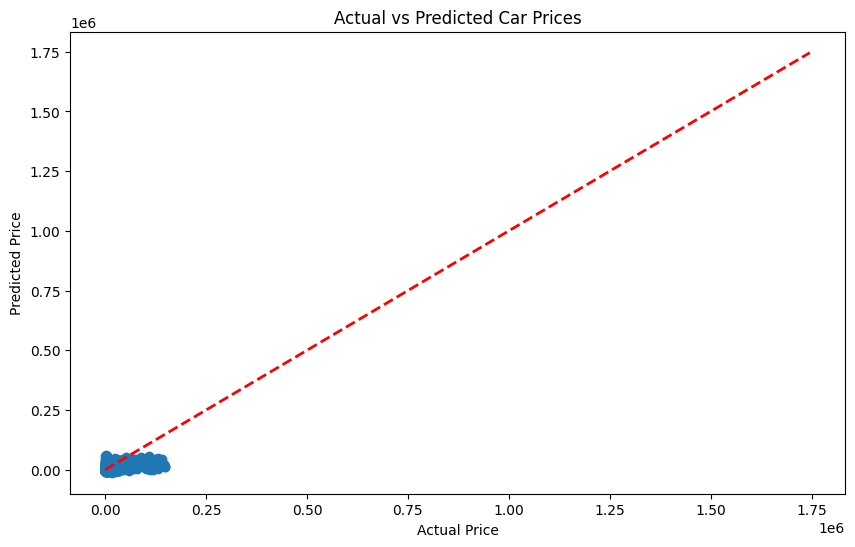

In [562]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([y_pred_final.min(),y_pred_final.max()], [y_pred_final.min(), y_pred_final.max()], '--r', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

## 🌳 Decision Tree Model

Decision Tree improves performance:

- Lower error  
- Better handling of non-linear relationships  

In [564]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [565]:
y_pred = dt.predict(X_test)
y_pred

array([ 1396.58333333,   888.        ,  4444.        , ...,
        2083.33333333, 17804.33333333, 10988.33333333])

In [566]:
mean_squared_error(y_pred,y_test)

16387300.847235566

In [567]:
mean_absolute_error(y_pred,y_test)

1634.204655463756

In [568]:
r2_score(y_pred,y_test)

0.7421437053778415

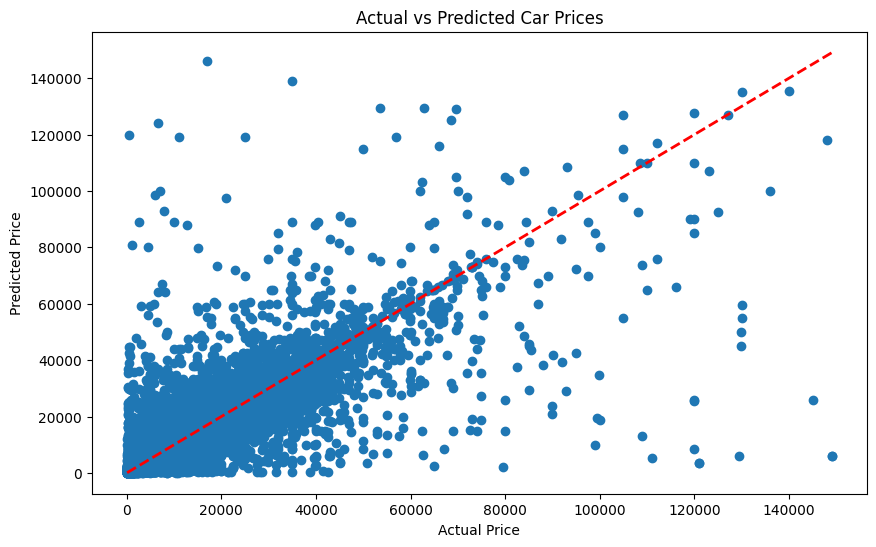

In [569]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

## 🌲 Random Forest Model

Random Forest provides the best performance:

- High accuracy  
- R² score ~0.74  

Insight:
- Ensemble models outperform simple regression  

In [570]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [571]:
y_Pred = rf.predict(X_test)
y_Pred

array([ 1376.96735365,  1558.91461785,  3883.37      , ...,
        2098.35040793, 17913.81152107, 11021.54560967])

In [572]:
mean_squared_error(y_pred,y_test)

16387300.847235566

In [573]:
mean_absolute_error(y_pred,y_test)

1634.204655463756

In [574]:
r2_score(y_pred,y_test)

0.7421437053778415

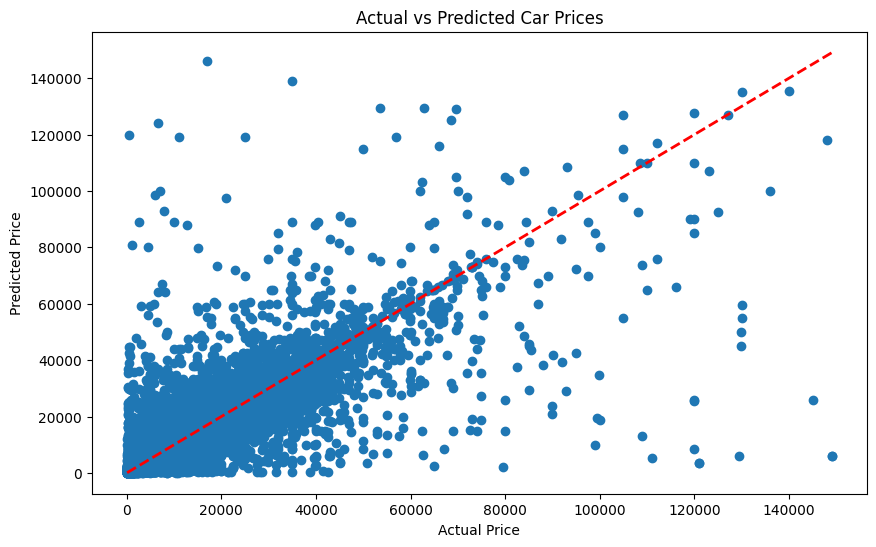

In [575]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()

🏁 FINAL COMPARISON

| Model             | R² Score | MAE   | Performance |
| ----------------- | -------- | ----- | ----------- |
| Linear Regression | 0.27     | 3060  | ❌ Poor      |
| Linear + Log      | 0.67     | 2667  | ⚠️ Medium   |
| Decision Tree     | 0.74     | 1634  | ✅ Good      |
| Random Forest     | ~0.74    | ~1634 | 🚀 Best     |


## 🧠 Key Insights

- Car price is strongly influenced by power and year  
- Mileage negatively affects price  
- Premium brands and fuel types increase value  
- Machine learning models significantly improve prediction accuracy  

## 📌 Conclusion

This project demonstrates how machine learning can effectively predict car prices using real-world data. Advanced models like Random Forest outperform linear regression by capturing complex relationships between features.

## 🔮 Future Work

- Use advanced models like XGBoost  
- Perform hyperparameter tuning  
- Deploy as web app using Streamlit  
- Include additional features like location and demand  